In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = pd.Series([
    0.64, 0.62, 0.68, 0.72, 0.59, 0.52, 0.76, 0.66, 0.60, 0.56, 0.70, 0.68,
    0.66, 0.50, 0.62, 0.60, 0.72, 0.70, 0.64, 0.61, 0.63, 0.66, 0.58, 0.79,
    0.75, 0.69, 0.67, 0.82, 0.58, 0.55, 0.65, 0.67, 0.51, 0.69, 0.75, 0.82,
    0.54, 0.57, 0.69, 0.53, 0.71, 0.58, 0.74, 0.79, 0.70, 0.73, 0.56, 0.59,
    0.66, 0.64, 0.68, 0.63, 0.76, 0.61, 0.57, 0.65, 0.67, 0.78, 0.73, 0.50,
    0.74, 0.61, 0.77, 0.65, 0.66, 0.71, 0.68, 0.52, 0.68, 0.63, 0.57, 0.63,
    0.66, 0.74, 0.64, 0.77, 0.80, 0.73, 0.81, 0.63, 0.53, 0.80, 0.68, 0.81,
    0.71, 0.80, 0.67, 0.65, 0.50, 0.67, 0.56, 0.60, 0.67, 0.62, 0.77, 0.51,
    0.61, 0.62, 0.62, 0.59
])

In [4]:
h = 0.04
Alpha = 0.05
gamma = 0.95

In [5]:
data_min = min(data)
data_max = max(data)
delta = data_max - data_min
interval_number = int(round(delta / h))

print('Минимум: ', data_min)
print('Максимум: ', data_max)
print('Размах значений: ', delta)
print('Кол-во интервалов: ', interval_number)

Минимум:  0.5
Максимум:  0.82
Размах значений:  0.31999999999999995
Кол-во интервалов:  8


In [6]:
xi = []
start = data_min + h/2
current = start
while current < data_max:
    xi.append(round(current, 4))
    current += h
print('Центры интервалов:', xi)

Центры интервалов: [0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8]


In [8]:
bins = [data_min + i*h for i in range(interval_number+1)]
bins = [round(b, 4) for b in bins]   # округл. границ

ni = [0] * interval_number

for val in data:
    for idx in range(interval_number):
        if idx == 0:
            if bins[0] <= val <= bins[1]:
                ni[idx] += 1
                break
        else:
            if bins[idx] < val <= bins[idx+1]:
                ni[idx] += 1
                break

print('Частоты ni:', ni)
print('Сумма частот:', sum(ni))
n = sum(ni)

Частоты ni: [10, 10, 15, 19, 18, 11, 8, 9]
Сумма частот: 100


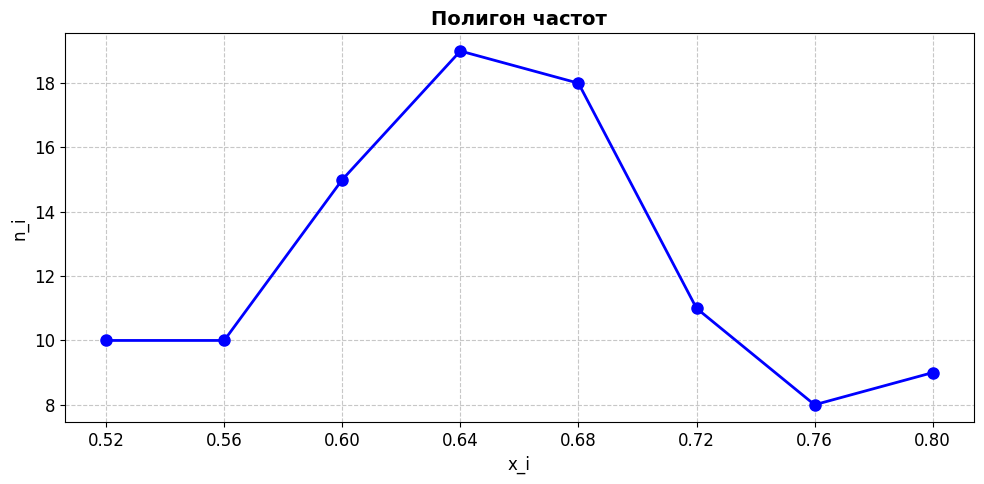

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(xi, ni, marker='o', color='blue', markersize=8, linewidth=2)
plt.title('Полигон частот', fontsize=14, fontweight='bold')
plt.xlabel('x_i', fontsize=12)
plt.ylabel('n_i', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(xi)
plt.tight_layout()
plt.show()

In [88]:
wi = [w/100 for w in ni]
intervalsXiWi = pd.DataFrame([xi, wi])
intervalsXiWi

,0,1,2,3,4,5,6,7
0,0.52,0.56,0.60,0.64,0.68,0.72,0.76,0.80
1,0.10,0.10,0.15,0.19,0.18,0.11,0.08,0.09


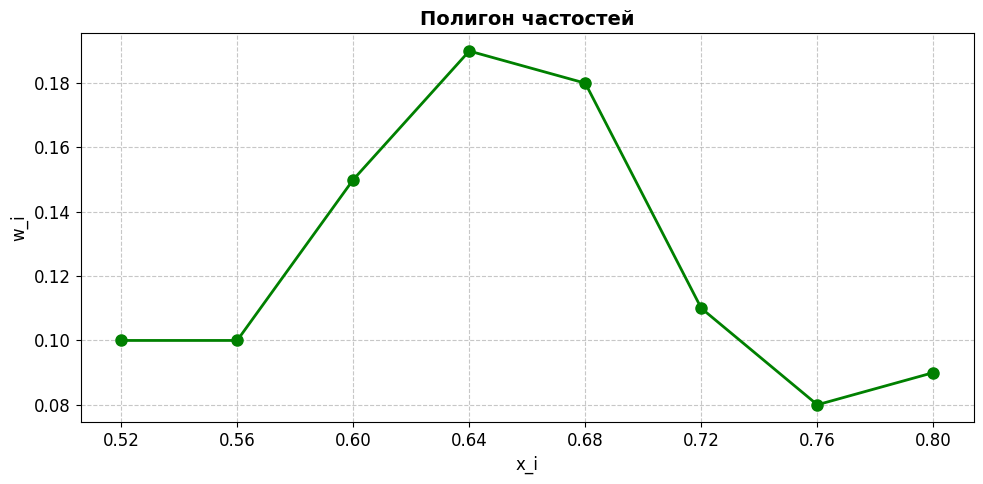

In [73]:
wi = [w / n for w in ni]
plt.figure(figsize=(10, 5))
plt.plot(xi, wi, marker='o', color='green', markersize=8, linewidth=2)
plt.title('Полигон частостей', fontsize=14, fontweight='bold')
plt.xlabel('x_i', fontsize=12)
plt.ylabel('w_i', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(xi)
plt.tight_layout()
plt.show()

In [75]:
niH = [n / h for n in ni]
intervalsXiNiforH = pd.DataFrame([xi, niH]) # Данные для гистограммы
intervalsXiNiforH

,0,1,2,3,4,5,6,7
0,0.52,0.56,0.6,0.64,0.68,0.72,0.76,0.8
1,250.00,250.00,375.0,475.00,450.00,275.00,200.00,225.0


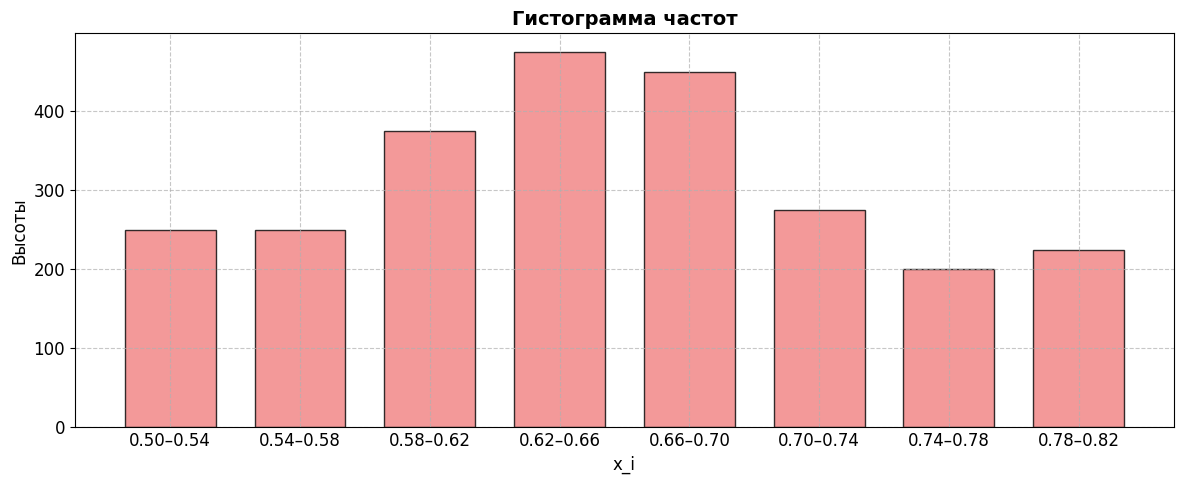

In [81]:
interval_labels = [f'{bins[i]:.2f}–{bins[i+1]:.2f}' for i in range(len(bins)-1)]

plt.figure(figsize=(12, 5))
plt.bar(x=bins[:-1], height=niH, width=0.7*h, align='edge',
        edgecolor='black', color='lightcoral', alpha=0.8)

plt.title('Гистограмма частот', fontsize=14, fontweight='bold')
plt.xlabel('x_i', fontsize=12)
plt.ylabel('Высоты', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')

x_positions = [bins[i] + 0.7*h/2 for i in range(len(bins)-1)]
plt.xticks(x_positions, interval_labels, rotation=0, ha='center')
plt.tick_params(axis='x', which='both', length=0)

plt.tight_layout()
plt.show()

In [85]:
wiH = [w / h for w in wi]
intervalsXiWiforH = pd.DataFrame([xi, wiH]) # Данные для гистограммы
intervalsXiWiforH

,0,1,2,3,4,5,6,7
0,0.52,0.56,0.60,0.64,0.68,0.72,0.76,0.80
1,2.50,2.50,3.75,4.75,4.50,2.75,2.00,2.25


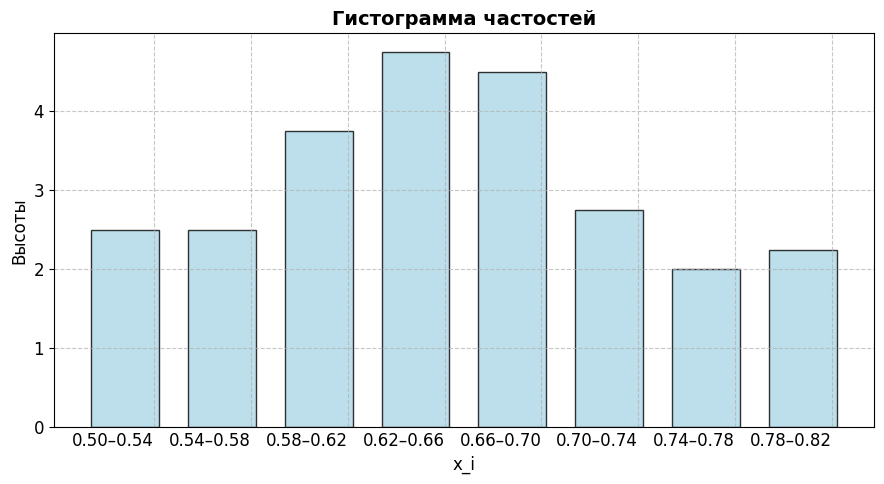

In [173]:
interval_labels = [f'{bins[i]:.2f}–{bins[i+1]:.2f}' for i in range(len(bins)-1)]

plt.figure(figsize=(9, 5))
plt.bar(x=bins[:-1], height=wiH, width=0.7*h, align='edge',
        edgecolor='black', color='lightblue', alpha=0.8)

plt.title('Гистограмма частоcтей', fontsize=14, fontweight='bold')
plt.xlabel('x_i', fontsize=12)
plt.ylabel('Высоты', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')

x_positions = [bins[i] + 1.3*h/2 for i in range(len(bins)-1)]
plt.tick_params(axis='x', which='both', length=0)
plt.xticks(x_positions, interval_labels, rotation=0, ha='right')

plt.tight_layout()
plt.show()

In [89]:
emp_func = list(round(intervalsXiWi.iloc[1].cumsum(), 4)) # Эмпирическая функция распределения
emp_func

[0.1, 0.2, 0.35, 0.54, 0.72, 0.83, 0.91, 1.0]

In [129]:
func_dataY = []
func_dataX = []

for i in emp_func:
  func_dataY.append(i)
  func_dataY.append(i)

for i in xi:
  func_dataX.append(i)
  func_dataX.append(i+h)

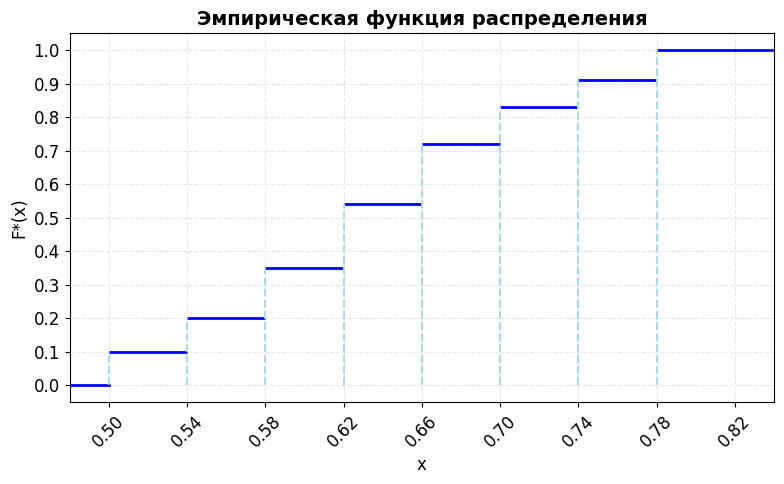

In [149]:
bins = [0.50, 0.54, 0.58, 0.62, 0.66, 0.70, 0.74, 0.78, 0.82]

plt.figure(figsize=(8, 5))

plt.plot([0.46, 0.50], [0, 0], color='blue', linewidth=2)

for i in range(len(emp_func)):
    plt.plot([bins[i], bins[i+1]], [emp_func[i], emp_func[i]],
             color='blue', linewidth=2, solid_capstyle='butt')

plt.plot([0.82, 0.84], [1.00, 1.00], color='blue', linewidth=2)

for i in range(len(bins)-1):
    y_top = emp_func[i]
    plt.vlines(x=bins[i], ymin=0, ymax=y_top,
               color='lightblue', linestyle="dashed", linewidth=1.5)

plt.xlim(0.48, 0.84)
plt.ylim(-0.05, 1.05)
plt.xticks(np.arange(0.50, 0.85, 0.04), rotation=45)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title('Эмпирическая функция распределения', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('F*(x)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [150]:
C = [xi[i] for i in range (len(ni)) if ni[i]==max(ni)][0] # Значение с максимальной частотой
C

0.64

In [168]:
# Условные варианты

alpha = [(xi[i]-C)/h for i in range (len(ni))]
alphani=[alpha[i]*ni[i] for i in range (len(ni))]
alpha2ni=[ni[i]*(alpha[i]**2) for i in range (len(ni))]
alpha3ni=[ni[i]*(alpha[i]**3) for i in range (len(ni))]
alpha4ni=[ni[i]*(alpha[i]**4) for i in range (len(ni))]

alphas = [alphani, alpha2ni, alpha3ni, alpha4ni]
alphasDF = pd.DataFrame([["xi"]+xi, ["ni"]+ni, ["a"]+alpha, ["a*ni"]+alphani, ["a2ni"]+alpha2ni,["a3ni"]+alpha3ni,["a4ni"]+alpha4ni])
alphasDF # Склейка

print(sum(alphani))
print(sum(alpha2ni))
print(sum(alpha3ni))
print(sum(alpha4ni))

35.000000000000014
423.0
533.0000000000003
4131.000000000001


In [156]:
moments = [int(sum(alphas[i]))/100 for i in range (4)] # Условные эмпирические моменты
moments

[0.35, 4.23, 5.33, 41.31]

In [157]:
# Искомые величины

X = moments[0]*h+C
D = (moments[1]-moments[0]**2)*h*h
sigma = round(D**0.5, 3)
V=round(sigma/X*100, 3)
a = round((moments[2]-3*moments[1]*moments[0]+2*(moments[0]**3))*((h/sigma)**3), 3)
e = round((moments[3]-4*moments[2]*moments[0]+6*moments[1]*(moments[0]**2)-3*(moments[0]**4))*((h/sigma)**4)-3, 3)

print ('X :', X)
print ('D :', D)
print ('Sigma :', sigma)
print ('V :', V,'%')
print ('a :', a)
print ('e :', e)

X : 0.654
D : 0.0065720000000000015
Sigma : 0.081
V : 12.385 %
a : 0.117
e : -0.805


In [158]:
def classif(a, e):
  if a==0 and e==0: print('Идеальное нормальное распределение')
  elif abs(a)<0.1 and abs(e)<1: print('Нормальное распределение')
  elif abs(a)<0.5 and abs(e)<0.5: print('Распределение близкое к нормальному')
  elif abs(a)<1 and abs(e)<1: print('Распределение нормального типа')
  else: print('Не нормальное распределение')


In [159]:
# выводы о распределении
classif (a, e)

Распределение нормального типа


In [160]:
def laplas(x): # Функция Лапласа
  a=(1/((6.28)**0.5))*(2.713**(-0.5*x**2))
  return round(a, 3)

In [161]:
xiX=[xi[i]-X for i in range (len(xi))]
ui = [round(xiX[i]/sigma, 3) for i in range (len(xiX))]
fui = [laplas(ui[i]) for i in range (len(ui))]
yi = [round(100*h/sigma*fui[i], 4) for i in range (len(fui))]
ni1 = [round(yi[i], 0) for i in range (len(yi))]

normDF = pd.DataFrame([['xi']+xi, ['ni']+ni, ['xi-X']+xiX, ['ui']+ui, ['Ф(ui)']+fui, ['yi']+yi, ["ni'"]+ni1])
normDF # Опытные данные нормального распределения

,0,1,2,3,4,5,6,7,8
0,xi,0.520,0.5600,0.6000,0.6400,0.680,0.7200,0.7600,0.8000
1,ni,10.000,10.0000,15.0000,19.0000,18.000,11.0000,8.0000,9.0000
2,xi-X,-0.134,-0.0940,-0.0540,-0.0140,0.026,0.0660,0.1060,0.1460
3,ui,-1.654,-1.1600,-0.6670,-0.1730,0.321,0.8150,1.3090,1.8020
4,Ф(ui),0.102,0.2040,0.3200,0.3930,0.379,0.2860,0.1700,0.0790
5,yi,5.037,10.0741,15.8025,19.4074,18.716,14.1235,8.3951,3.9012
6,ni',5.000,10.0000,16.0000,19.0000,19.000,14.0000,8.0000,4.0000


In [ ]:
normDF  # Опытные данные нормального распределения

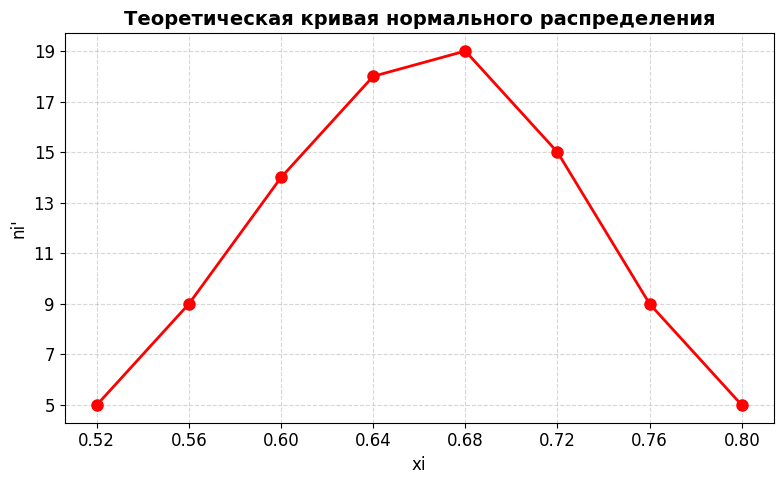

In [186]:
plt.figure(figsize=(8, 5))
plt.plot(xi, ni1, marker='o', color='red', linewidth=2, markersize=8, label='Теоретические частоты ni\'')

plt.title('Теоретическая кривая нормального распределения', fontsize=14, fontweight='bold')
plt.xlabel('xi', fontsize=12)
plt.ylabel('ni\'', fontsize=12)

plt.xticks(xi)

plt.yticks(range(5, 21, 2))

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [163]:
nin = [ni[i] - ni1[i] for i in range(len(ni))]
nin2 = [nin[i]**2 for i in range(len(nin))]

nin21 = [round(nin2[i]/ni1[i], 3) if ni1[i] != 0 else 0 for i in range(len(nin2))]

nDF = pd.DataFrame([['xi'] + xi, ['ni'] + ni, ["ni'"] + ni1, ["ni-ni'"] + nin, ["(ni-ni')^2"] + nin2, ["((ni-ni')^2)/ni'"] + nin21])
nDF

,0,1,2,3,4,5,6,7,8
0,xi,0.52,0.56,0.600,0.64,0.680,0.720,0.76,0.80
1,ni,10.00,10.00,15.000,19.00,18.000,11.000,8.00,9.00
2,ni',5.00,10.00,16.000,19.00,19.000,14.000,8.00,4.00
3,ni-ni',5.00,0.00,-1.000,0.00,-1.000,-3.000,0.00,5.00
4,(ni-ni')^2,25.00,0.00,1.000,0.00,1.000,9.000,0.00,25.00
5,((ni-ni')^2)/ni',5.00,0.00,0.062,0.00,0.053,0.643,0.00,6.25


In [164]:
nabludaemoe = sum(nin21)
float(nabludaemoe)

12.008

In [165]:
deltaX = round(1.984*sigma/10, 3)
deltaX

0.016

In [166]:
Xbounds = [X-deltaX, X+deltaX]
print (Xbounds[0], '< мат ожидание <', Xbounds[1]) # границы мат ожидания

0.638 < мат ожидание < 0.67
